<a href="https://colab.research.google.com/github/abrown9008/RJS-Baseball/blob/main/Spencer_Strider_2026_Injury_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
if (!dir.exists("RJS-Baseball")) {
  # Execute git clone
  system("git clone https://github.com/abrown9008/RJS-Baseball")
  # After cloning, verify if the directory was created
  if (!dir.exists("RJS-Baseball")) {
    stop("Failed to clone the RJS-Baseball repository. Please check your internet connection or the repository URL.")
  }
}

setwd("RJS-Baseball")

In [4]:
install.packages(c('tidyverse','baseballr'))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘snakecase’, ‘janitor’, ‘RcppParallel’




In [5]:
library(tidyverse)
library(baseballr)

## Get Spencer Strider ids ##

ss_id <- playerid_lookup("Strider","Spencer")
View(ss_id)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


first_name,last_name,given_name,name_suffix,nick_name,birth_year,mlb_played_first,mlbam_id,retrosheet_id,bbref_id,fangraphs_id
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>
Spencer,Strider,Spencer Robert,,,1998,2021,675911,stris002,stridsp01,27498


In [6]:
## Get Strider's game logs ##

ss_gl <- fg_pitcher_game_logs(playerid = ss_id$fangraphs_id,
                              year = 2026)

View(ss_gl)

PlayerName,playerid,Date,Opp,teamid,season,Team,HomeAway,Age,W,⋯,Events,EV,LA,Barrels,Barrel%,maxEV,HardHit,HardHit%,gamedate,dh
<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
Spencer Strider,27498,2026-06-12,@NYM,16,2026,ATL,A,27,0,⋯,12,87.35833,16.91667,2,0.16666667,109.1,5,0.4166667,2026-06-12,0
Spencer Strider,27498,2026-06-06,PIT,16,2026,ATL,H,27,1,⋯,16,90.56875,26.50000,2,0.12500000,108.5,7,0.4375000,2026-06-06,0
Spencer Strider,27498,2026-05-31,@CIN,16,2026,ATL,A,27,0,⋯,14,89.10000,21.21429,2,0.14285714,111.5,5,0.3571429,2026-05-31,0
Spencer Strider,27498,2026-05-26,@BOS,16,2026,ATL,A,27,1,⋯,13,90.76923,28.84615,1,0.07692308,107.6,4,0.3076923,2026-05-26,0
Spencer Strider,27498,2026-05-21,@MIA,16,2026,ATL,A,27,1,⋯,13,93.04167,17.66667,2,0.15384615,105.6,5,0.3846154,2026-05-21,0
Spencer Strider,27498,2026-05-15,BOS,16,2026,ATL,H,27,0,⋯,11,80.78182,24.45455,0,0.00000000,96.0,2,0.1818182,2026-05-15,0
Spencer Strider,27498,2026-05-09,@LAD,16,2026,ATL,A,27,1,⋯,11,90.92727,16.72727,1,0.09090909,106.5,4,0.3636364,2026-05-09,0
Spencer Strider,27498,2026-05-03,@COL,16,2026,ATL,A,27,0,⋯,8,88.96250,23.00000,1,0.12500000,103.9,4,0.5000000,2026-05-03,0


In [18]:
ss_gl2 <- ss_gl |>
  select(PlayerName,Date,Opp,WHIP)

#install.packages('Lahman')

## Calculate Mean/SD for WHIP for 2025 Regular
## Season for Pitcher who had more than 15 IP ##

whip_df <- Lahman::Pitching |>
  filter(yearID == 2025) |>
  group_by(playerID) |>
  summarise(whip = sum(BB + H) / sum(IPouts) * 3,
            IP = sum(IPouts) / 3) |>
  filter(IP >= 15) |>
  ungroup() |>
  summarise(mean_whip = mean(whip,na.rm=T),
            sd_whip = sd(whip,na.rm=T))

  print(whip_df)

# A tibble: 1 × 2
  mean_whip sd_whip
      <dbl>   <dbl>
1      1.31   0.252


In [21]:
## Build CUSUM Control Chart ##

d <- 2
USL <- whip_df$mean_whip + d * whip_df$sd_whip
k <- abs(USL - d) / 2

CUSUM <- vector('double',length=nrow(ss_gl2))

ss_gl2 <- ss_gl2 |>
  arrange(Date) |>
  mutate(W = if_else(is.na(WHIP),0,(USL-WHIP)/whip_df$sd_whip))

for(i in 1:length(CUSUM)){

  n <- nrow(CUSUM)

  if(i == 1){
    CUSUM[i] <- max(0,d-k-ss_gl2$W[i])
  } else{
    CUSUM[i] <- max(0,CUSUM[i-1] + d - k - ss_gl2$W[i])

  }

}

ss_gl2$CUSUM <- CUSUM
print(CUSUM)
View(ss_gl2)

[1] 5.409809 2.090765 1.251508 0.000000 0.000000 1.838914 2.090764 6.045763


PlayerName,Date,Opp,WHIP,W,CUSUM
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Spencer Strider,2026-05-03,@COL,2.7000003,-3.50100106,5.409809
Spencer Strider,2026-05-09,@LAD,0.5000000,5.22785223,2.090765
Spencer Strider,2026-05-15,BOS,1.1250001,2.74806439,1.251508
Spencer Strider,2026-05-21,@MIA,0.9473685,3.45284620,0.000000
Spencer Strider,2026-05-26,@BOS,1.2000000,2.45049014,0.000000
Spencer Strider,2026-05-31,@CIN,1.8000000,0.06989407,1.838914
Spencer Strider,2026-06-06,PIT,1.4000000,1.65695812,2.090764
Spencer Strider,2026-06-12,@NYM,2.3333333,-2.04619133,6.045763


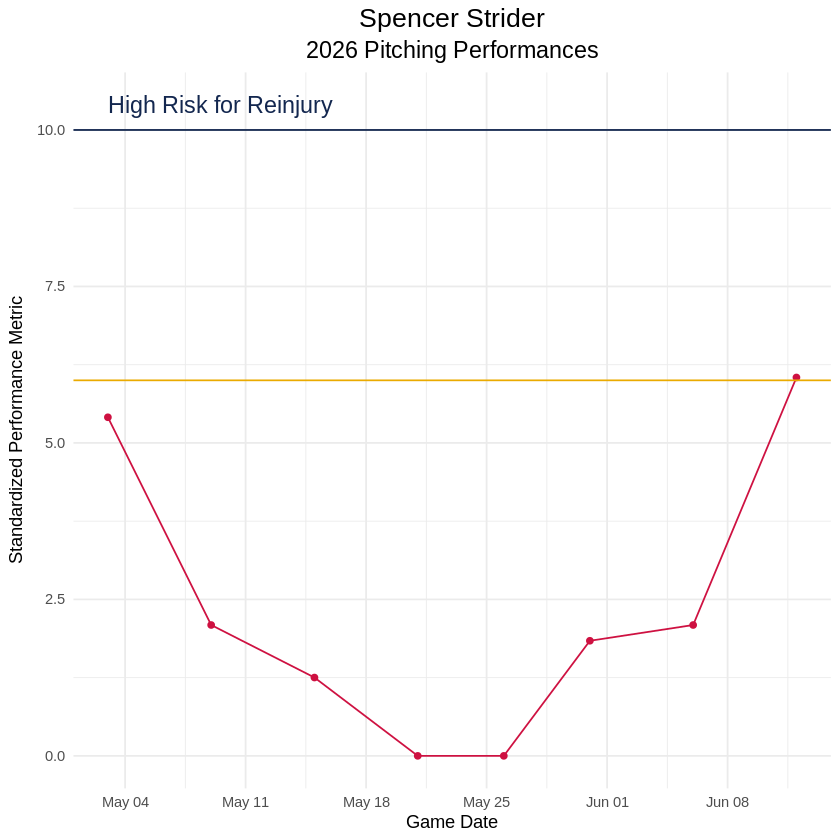

In [30]:
## Visualize Performance ##

ss_gl2 <- ss_gl2 |>
  mutate(Date = as.Date(Date))

ss_gl2 |>
  ggplot(aes(x = Date, y = CUSUM)) +
  geom_point(color="#CE1141") +
  geom_line(color="#CE1141") +
  geom_hline(yintercept=10,color='#13274F') +
  geom_hline(yintercept=6,color='#EAAA00') +
  annotate("text", x = min(ss_gl2$Date), y = 10.4,
           label = "High Risk for Reinjury",
           color = "#13274F", size = 14/.pt, hjust = 0) +
  labs(x = "Game Date",
       y = "Standardized Performance Metric",
       title = "Spencer Strider",
       subtitle = "2026 Pitching Performances") +
  theme_minimal() +
  theme(plot.title=element_text(hjust=0.5,size=16),
        plot.subtitle=element_text(hjust=0.5,size=14))

In [31]:
ggsave("strider_cusum.png", width = 10, height = 6, dpi = 300, bg = "white")